# 05. Однослойная нейросеть (MLP)

Один скрытый слой `Dense(64, relu)` + softmax.

In [1]:
from pathlib import Path
import sys
import os

for _p in (Path.cwd(), Path.cwd().parent):
    if (_p / "src" / "helpers.py").is_file():
        sys.path.insert(0, str((_p / "src").resolve()))
        os.chdir(_p)
        break

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [2]:
from helpers import init_notebook_path, ensure_dirs, PROJECT_ROOT, PLOT_DIR, DATA_DIR, RANDOM_STATE
ROOT = init_notebook_path()
ensure_dirs()
print("PROJECT_ROOT", PROJECT_ROOT)

PROJECT_ROOT /home/eq/techlb/курсовые/Асташёнок/comparative analysis of different approaches


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix
import seaborn as sns
from helpers import load_xy_from_processed, classification_metrics_dict, print_report, append_metrics_store, PLOT_DIR, CLASS_NAMES, RANDOM_STATE

2026-04-24 22:33:54.228627: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-24 22:33:54.228663: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-24 22:33:54.229859: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
tf.keras.utils.set_random_seed(RANDOM_STATE)
X_train, X_val, X_test, y_train, y_val, y_test, _ = load_xy_from_processed()
n_classes = len(CLASS_NAMES)
model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(n_classes, activation='softmax'),
])


In [5]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                576       
                                                                 
 dense_1 (Dense)             (None, 4)                 260       
                                                                 
Total params: 836 (3.27 KB)
Trainable params: 836 (3.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [6]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

cb = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')
]

h = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=120, batch_size=64, callbacks=cb, verbose=1)

Epoch 1/120
88/88 [==============================] - 0s 2ms/step - loss: 1.0332 - accuracy: 0.5784 - val_loss: 0.7882 - val_accuracy: 0.6617
Epoch 2/120
88/88 [==============================] - 0s 914us/step - loss: 0.6738 - accuracy: 0.6730 - val_loss: 0.5919 - val_accuracy: 0.6842
Epoch 3/120
88/88 [==============================] - 0s 885us/step - loss: 0.5518 - accuracy: 0.7068 - val_loss: 0.5239 - val_accuracy: 0.7133
Epoch 4/120
88/88 [==============================] - 0s 901us/step - loss: 0.5026 - accuracy: 0.7127 - val_loss: 0.4908 - val_accuracy: 0.7225
Epoch 5/120
88/88 [==============================] - 0s 889us/step - loss: 0.4765 - accuracy: 0.7166 - val_loss: 0.4710 - val_accuracy: 0.7125
Epoch 6/120
88/88 [==============================] - 0s 834us/step - loss: 0.4600 - accuracy: 0.7227 - val_loss: 0.4592 - val_accuracy: 0.7150
Epoch 7/120
88/88 [==============================] - 0s 873us/step - loss: 0.4467 - accuracy: 0.7318 - val_loss: 0.4466 - val_accuracy: 0.7183
E

In [7]:
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
m = classification_metrics_dict(y_test, y_pred)

print(m)
print_report(y_test, y_pred)

{'accuracy': 0.77, 'precision_macro': 0.7713248798709347, 'recall_macro': 0.77, 'f1_macro': 0.7678258542708557, 'precision_micro': 0.77, 'recall_micro': 0.77, 'f1_micro': 0.77}
              precision    recall  f1-score   support

    OPEN_SEA       0.97      1.00      0.99       300
 COASTAL_SEA       0.55      0.65      0.59       300
  NEAR_COAST       0.57      0.46      0.51       300
   COASTLINE       1.00      0.97      0.98       300

    accuracy                           0.77      1200
   macro avg       0.77      0.77      0.77      1200
weighted avg       0.77      0.77      0.77      1200



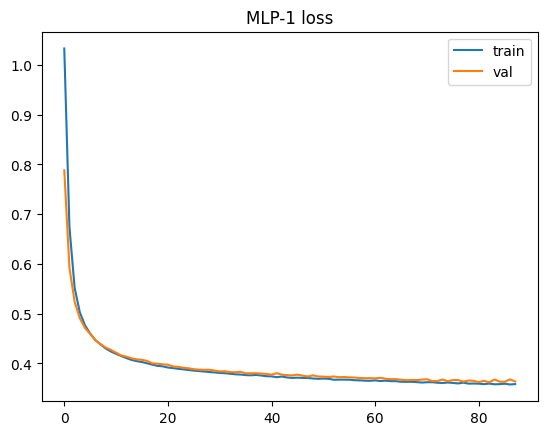

In [8]:
append_metrics_store('mlp_1hidden', m)
plt.figure()
plt.plot(h.history['loss'], label='train')
plt.plot(h.history['val_loss'], label='val')
plt.legend()
plt.title('MLP-1 loss'); plt.savefig(PLOT_DIR / 'mlp1_loss.png', dpi=150)
plt.show()
plt.close()

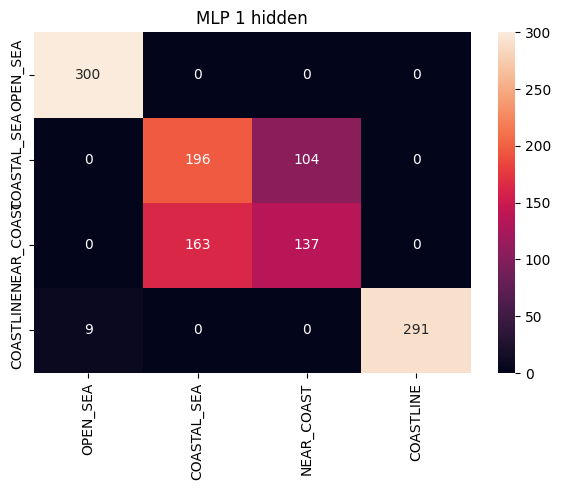

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(CLASS_NAMES)))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('MLP 1 hidden')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'confusion_mlp1.png', dpi=150)
plt.show()
plt.close()